##### ARTI 560 - Computer Vision

## Vision and Language (Multimodal AI with CLIP)

### Introduction

In this lab, we explore how images and text can be connected using a pre-trained model called **CLIP** developed by OpenAI. CLIP is trained on large-scale image–text pairs and learns to associate visual content with natural language descriptions.

We will apply CLIP to tasks such as zero-shot image classification, where the model can recognize objects in images using only text prompts, without needing additional training on labeled datasets. We will also explore image–text similarity, where the model measures how well a given caption matches an image.

### Objectives
1. Explore the intersection of Computer Vision and Natural Language Processing using joint embeddings.
2. Implement **Zero-Shot Image Classification** using OpenAI's CLIP via Hugging Face.
3. Implement **Text-to-Image Retrieval** (Image Search Engine)

## 1. Setup and Initialization

We begin by importing the required components from the Hugging Face `transformers` library, `PIL` for image preprocessing, and `matplotlib` for inline image visualization. We will also initialize the pre-trained **CLIP (Contrastive Language-Image Pre-training)** model and its corresponding processor.

In [2]:
import os
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoProcessor, CLIPModel
from transformers.image_utils import load_image

# Set up device configuration
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load model and processor from Hugging Face
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id).to(device)
processor = AutoProcessor.from_pretrained(model_id)
print("Model and Processor loaded successfully!")

c:\Users\sumay\anaconda3\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 9615.64it/s]


Model and Processor loaded successfully!


## 2. Basic Zero-Shot Classification

Zero-shot classification allows a model to categorize images into custom text bins *without* any fine-tuning. Here, we fetch a sample image from the COCO dataset, visualize it, and prompt CLIP to calculate the text-image matching similarity.

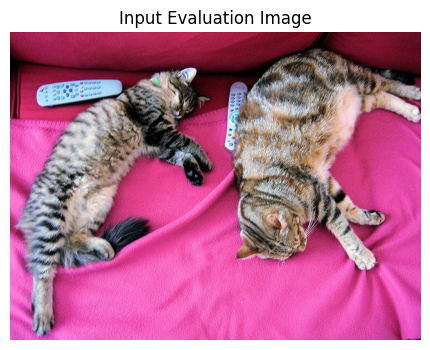


--- Classification Output ---
a photo of a cat    : 99.48%
a photo of a dog    : 0.52%


In [ ]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = load_image(url)

# Visualize the input image
plt.figure(figsize=(6, 4))
plt.imshow(image)
plt.title("Input Evaluation Image")
plt.axis("off")
plt.show()

# Candidate text labels
labels = ["a photo of a cat", "a photo of a dog"]

inputs = processor(
    text=labels, images=image, return_tensors="pt", padding=True
).to(device)

with torch.inference_mode():
    outputs = model(**inputs)

logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]

print("\n--- Classification Output ---")
for label, prob in zip(labels, probs):
    print(f"{label:<20}: {prob * 100:.2f}%")

## 3. Text-to-Image Search (Retrieval)

Because CLIP embeds text and images into the same vector space, we can match a singular text query against an entire array of images. 

*Note: This code automatically checks for your local lab files `data/image_0.jpg` through `data/image_4.jpg` and charts them visually side-by-side to highlight the matched result.*

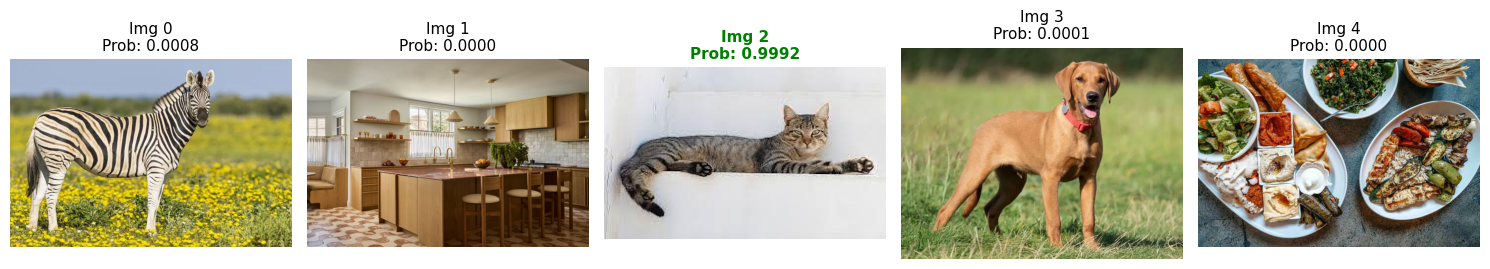

-> Query: 'a photo of a cat' matches best with Image index: 2


In [4]:
# Define target text query
target_text = ["a photo of a cat"]

# 1. Load the 5 images into a list of PIL Images safely
images = []
image_paths = [f"data/image_{i}.jpg" for i in range(5)]

for path in image_paths:
    if os.path.exists(path):
        images.append(load_image(path))
    else:
        # Fallback dummy images for demonstration if local files aren't available yet
        images.append(Image.new('RGB', (224, 224), color=(30, 140, i*40)))

# 2. Multi-modal processing
inputs = processor(
    text=target_text, 
    images=images,
    return_tensors="pt", 
    padding=True
).to(device)

# 3. Run inference
with torch.inference_mode():
    outputs = model(**inputs)
    logits_per_text = outputs.logits_per_text  
    probs = logits_per_text.softmax(dim=1).cpu().numpy()[0]

best_image_idx = probs.argmax()

# 4. Plot all images with their respective retrieval probability metrics
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, (img, prob) in enumerate(zip(images, probs)):
    axes[i].imshow(img)
    title_color = "green" if i == best_image_idx else "black"
    axes[i].set_title(f"Img {i}\nProb: {prob:.4f}", color=title_color, fontsize=11, fontweight='bold' if i == best_image_idx else 'normal')
    axes[i].axis("off")

plt.tight_layout()
plt.show()

print(f"-> Query: '{target_text[0]}' matches best with Image index: {best_image_idx}")

## 4. Scaling Up: Evaluation on CIFAR-100

Now let's verify CLIP's zero-shot classification profile against a standard evaluation bench: CIFAR-100. We pass 100 text prompts simultaneously into the text transformer, extract an index sample from the dataset, and plot the predictive distributions side-by-side.

In [11]:
from torchvision.datasets import CIFAR100

# Load evaluation partition of CIFAR100
cifar100 = CIFAR100(root=os.path.expanduser("~/.cache"), download=True, train=False)

# Grab target sample
sample_idx = 3637
image, class_id = cifar100[sample_idx]

# Construct prompt engineering array
text_prompts = [f"a photo of a {c}" for c in cifar100.classes]

inputs = processor(
    text=text_prompts, 
    images=image, 
    return_tensors="pt", 
    padding=True
).to(device)

with torch.inference_mode():
    outputs = model(**inputs)
logits_per_image = outputs.logits_per_image  
probs = logits_per_image.softmax(dim=1)[0]

# Extract Top-5 predictions
top5_values, top5_indices = probs.topk(5)
top5_values = top5_values.cpu().numpy()
top5_indices = top5_indices.cpu().numpy()

# Print text results
text_prompts = [f"a photo of a {c}" for c in cifar100.classes]
inputs = processor(text=text_prompts, images=image, return_tensors="pt", padding=True).to(device)

with torch.inference_mode():
    outputs = model(**inputs)
probs = outputs.logits_per_image.softmax(dim=1)[0]
top5_values, top5_indices = probs.topk(5)

print(f"\nGround Truth Label: {cifar100.classes[class_id]}\n\nTop Predictions:")
for value, index in zip(top5_values, top5_indices):
    print(f"{cifar100.classes[index]:>16s}: {100 * value.item():.2f}%")


Ground Truth Label: snake

Top Predictions:
           snake: 65.38%
          turtle: 12.25%
    sweet_pepper: 3.80%
          lizard: 1.87%
       crocodile: 1.75%
